In [9]:
import pymrio
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [8]:

# Load the original EXIOBASE data
exio3 = pymrio.parse_exiobase3(
    path=r"C:\Users\Dyde-nairn\Documents\python\i_o_scenarios\IOT_2022_pxp.v3.8.2.zip"
)


In [10]:

# Compute Leontief inverse manually
exio3.L = pymrio.calc_L(exio3.A)


In [11]:
# Step 1: Original final demand vector
original_vector = exio3.Y.sum(axis=1).copy()

# Step 2: Create shocked vector with 1% increase in French wind electricity
shock_vector = original_vector.copy()
shock_vector[("FR", "Electricity by wind")] *= 1.01

# Step 3: Combine into a DataFrame for comparison
comparison_df = pd.DataFrame({
    "Original Final Demand": original_vector,
    "Shocked Final Demand": shock_vector,
    "Difference": shock_vector - original_vector
})

# Step 4: Sort by difference to highlight the shock
comparison_df_sorted = comparison_df.sort_values(by="Difference", ascending=False)

# Step 5: Display the top rows
print(comparison_df_sorted.head(10))

                                                           Original Final Demand  \
region sector                                                                      
FR     Electricity by wind                                          1.329072e-01   
AT     Cereal grains nec                                            2.005656e+02   
       Vegetables, fruit, nuts                                      1.166912e+03   
       Oil seeds                                                    3.604377e+01   
       Sugar cane, sugar beet                                       3.403135e+00   
       Plant-based fibers                                           1.183007e-01   
       Crops nec                                                    8.715252e+01   
WM     Renting services of machinery and equipment wit...           1.507111e+04   
AT     Patent Fuel                                                  4.383183e-08   
       Paddy rice                                                   0.000000

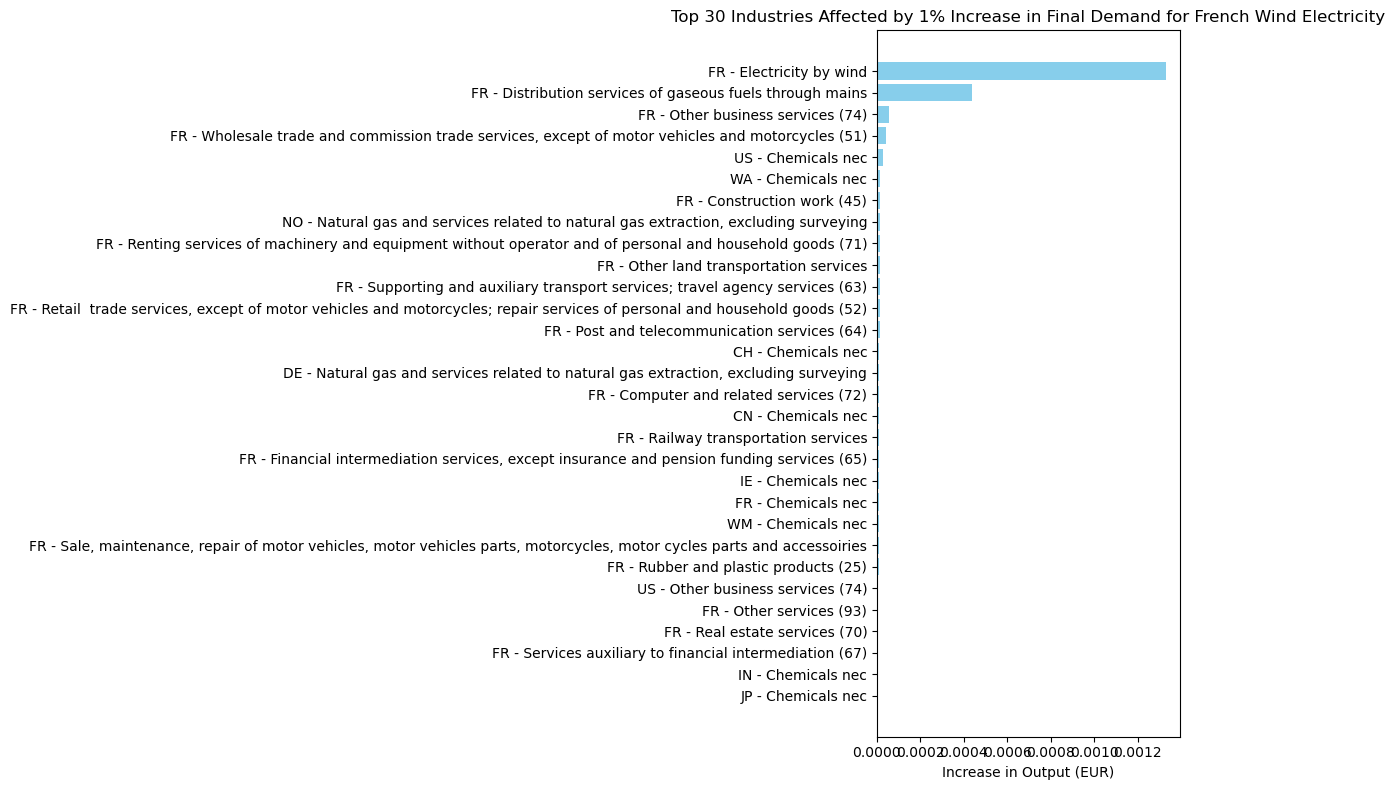

In [12]:

# Step 1: Original final demand vector
original_vector = exio3.Y.sum(axis=1).copy()

# Step 2: Shocked final demand vector (1% increase for French wind electricity)
shocked_vector = original_vector.copy()
shocked_vector[("FR", "Electricity by wind")] *= 1.01

# Step 3: Compute total output before and after the shock
original_output = exio3.L @ original_vector
shocked_output = exio3.L @ shocked_vector

# Step 4: Compute the difference in output
delta_output = shocked_output - original_output

# Step 5: Convert to DataFrame for sorting
delta_output_df = delta_output.reset_index()
delta_output_df.columns = ["Country", "Industry", "Output Change"]

# Step 6: Sort and select top 30 affected industries
top_30_affected = delta_output_df.sort_values(by="Output Change", ascending=False).head(30)

# Step 7: Plot the results
plt.figure(figsize=(12, 8))
plt.barh(top_30_affected["Country"] + " - " + top_30_affected["Industry"], top_30_affected["Output Change"], color='skyblue')
plt.title("Top 30 Industries Affected by 1% Increase in Final Demand for French Wind Electricity")
plt.xlabel("Increase in Output (EUR)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


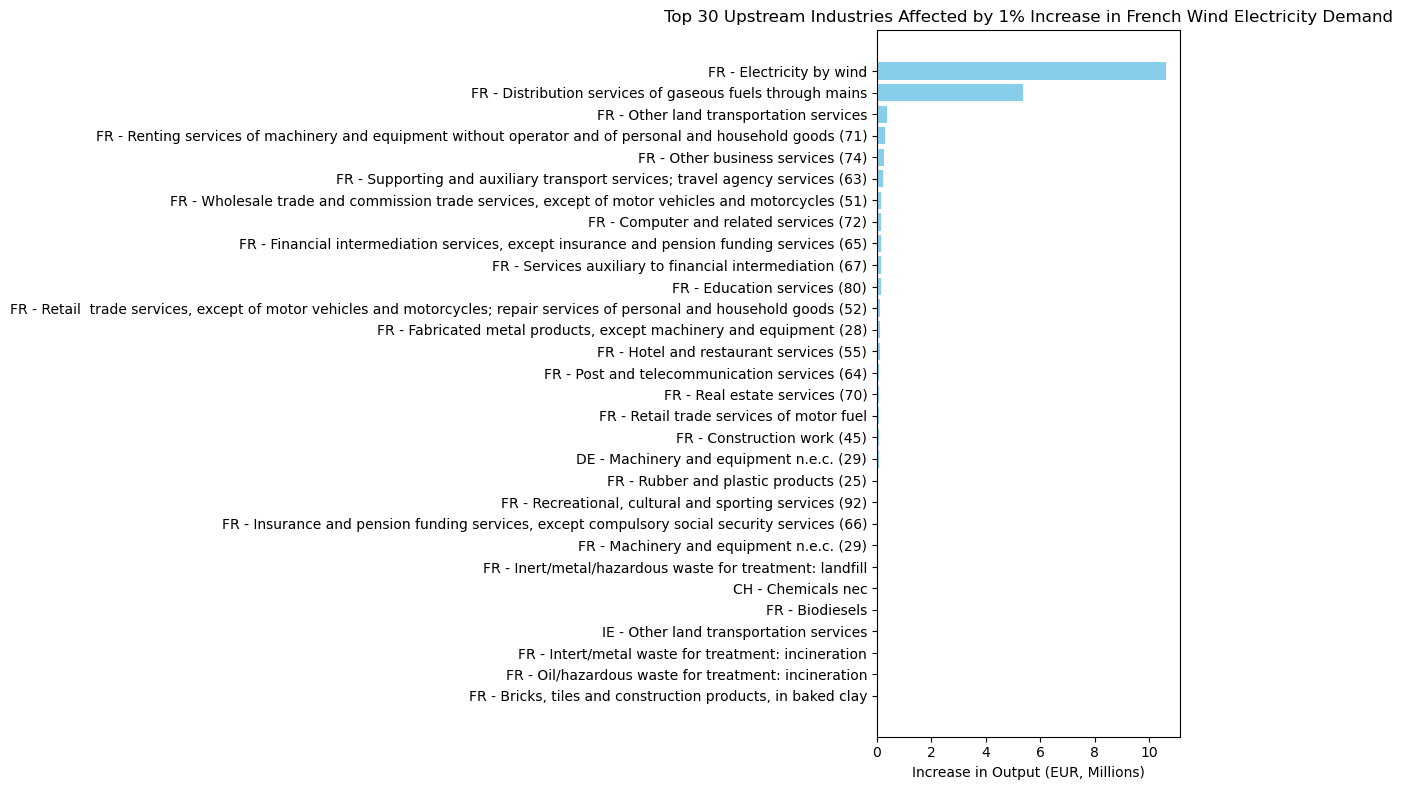

In [6]:

# Step 1: Get the total final demand value (sum across all categories)
original_demand = exio3.Y.loc[("FR", "Electricity by wind")].sum()

# Step 2: Create a shock vector with a 1% increase
shock_vector = pd.Series(0.0, index=exio3.L.columns)
shock_vector[("FR", "Electricity by wind")] = original_demand * 0.01

# Step 3: Calculate the change in output using the Leontief inverse
delta_output = exio3.L @ shock_vector

# Step 4: Convert to DataFrame for sorting
delta_output_df = delta_output.reset_index()
delta_output_df.columns = ["Country", "Industry", "Output Change"]

# Step 5: Sort and select top 30 affected industries
top_30_affected = delta_output_df.sort_values(by="Output Change", ascending=False).head(30)

# Step 6: Plot the results
plt.figure(figsize=(12, 8))
plt.barh(top_30_affected["Country"] + " - " + top_30_affected["Industry"], top_30_affected["Output Change"], color='skyblue')
plt.title("Top 30 Upstream Industries Affected by 1% Increase in French Wind Electricity Demand")
plt.xlabel("Increase in Output (EUR, Millions)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



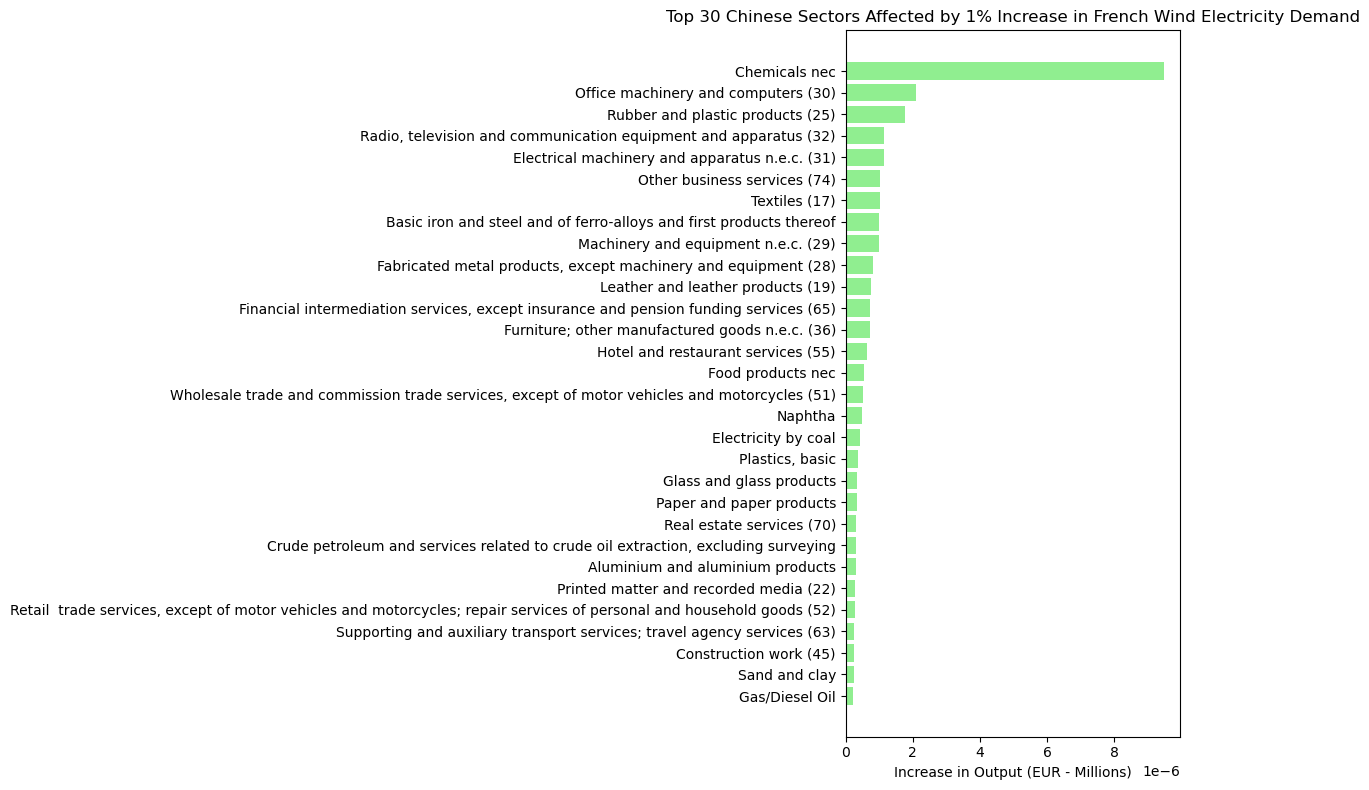

In [13]:

# Step 1: Get the total final demand value for French wind electricity
original_demand = exio3.Y.loc[("FR", "Electricity by wind")].sum()

# Step 2: Create a shock vector with a 10% increase
shock_vector = pd.Series(0.0, index=exio3.Y.index)
shock_vector[("FR", "Electricity by wind")] = original_demand * 0.01

# Step 3: Calculate the change in output using the Leontief inverse
delta_output = exio3.L @ shock_vector

# Step 4: Convert to DataFrame for sorting
delta_output_df = delta_output.reset_index()
delta_output_df.columns = ["Country", "Industry", "Output Change"]

# Step 5: Filter for China and get top 30 sectors
china_affected = delta_output_df[delta_output_df["Country"] == "CN"]
top_30_china = china_affected.sort_values(by="Output Change", ascending=False).head(30)

# Step 6: Plot the results
plt.figure(figsize=(12, 8))
plt.barh(top_30_china["Industry"], top_30_china["Output Change"], color='lightgreen')
plt.title("Top 30 Chinese Sectors Affected by 1% Increase in French Wind Electricity Demand")
plt.xlabel("Increase in Output (EUR - Millions)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


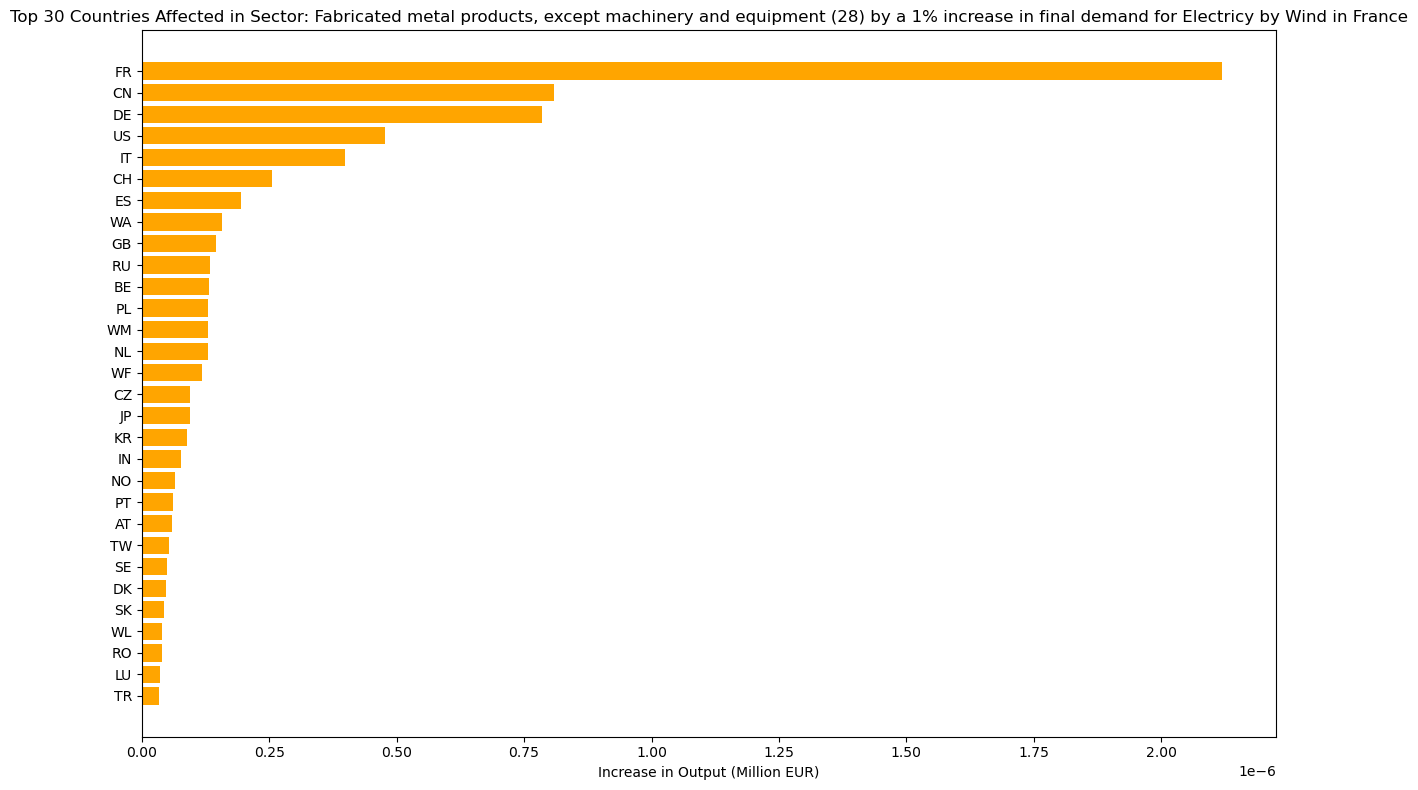

In [14]:

# Step 1: Get the total final demand value (sum across all categories)
original_demand = exio3.Y.loc[("FR", "Electricity by wind")].sum()

# Step 2: Create a shock vector with a 10% increase
shock_vector = pd.Series(0.0, index=exio3.Y.index)
shock_vector[("FR", "Electricity by wind")] = original_demand * 0.01  # 1% increase

# Step 3: Calculate the change in output using the Leontief inverse
delta_output = exio3.L @ shock_vector

# Step 4: Convert to DataFrame for filtering
delta_output_df = delta_output.reset_index()
delta_output_df.columns = ["Country", "Industry", "Output Change"]

# Step 5: Filter for the specific sector
sector_name = "Fabricated metal products, except machinery and equipment (28)"
filtered_sector = delta_output_df[delta_output_df["Industry"] == sector_name]

# Step 6: Sort and select top 30 countries affected
top_30_countries = filtered_sector.sort_values(by="Output Change", ascending=False).head(30)

# Step 7: Plot the results
plt.figure(figsize=(12, 8))
plt.barh(top_30_countries["Country"], top_30_countries["Output Change"], color='orange')
plt.title(f"Top 30 Countries Affected in Sector: {sector_name} by a 1% increase in final demand for Electricy by Wind in France" )
plt.xlabel("Increase in Output (Million EUR)")
plt.gca().invert_yaxis()
plt.tight_layout()

# Step 8: Save the figure BEFORE showing it
plt.savefig("wind_demand_france_fabricated_metals_effects_top30.png", dpi=300)
plt.show()


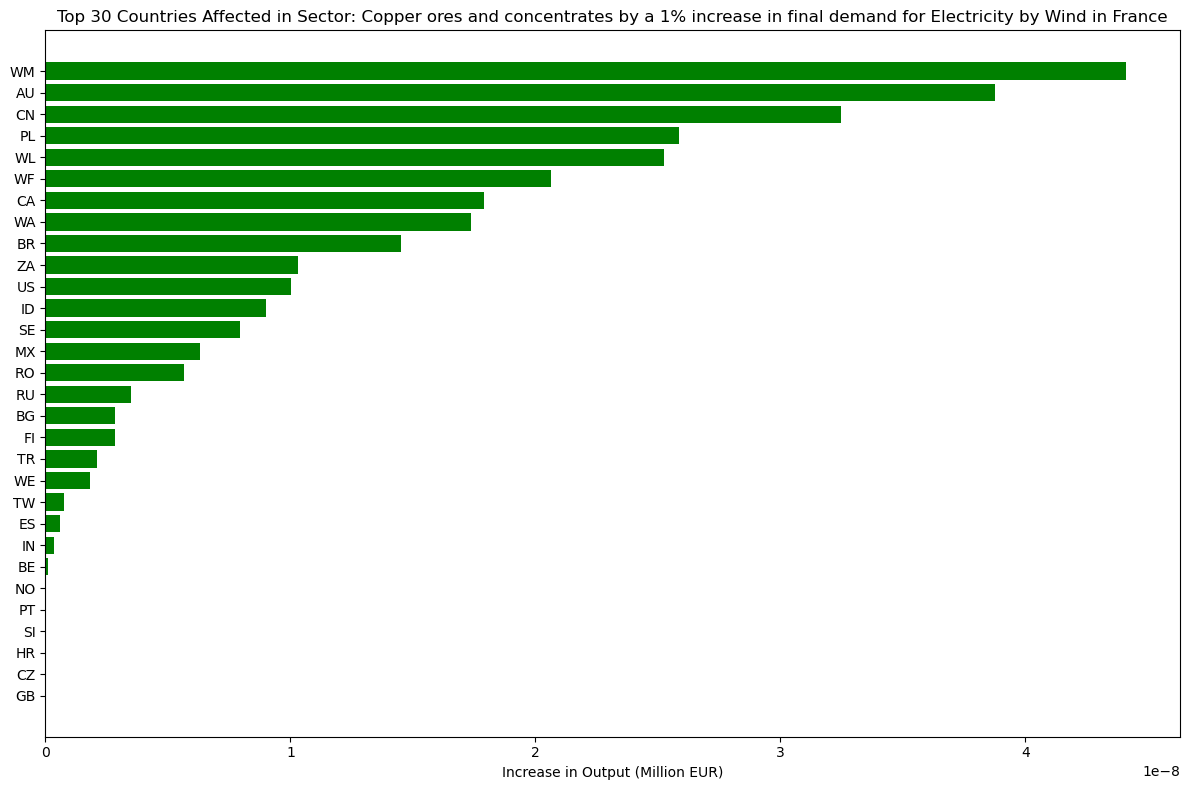

In [15]:
# Step 2: Create a shock vector with a 1% increase
shock_vector = pd.Series(0.0, index=exio3.Y.index)
shock_vector[("FR", "Electricity by wind")] = original_demand * 0.01  # 1% increase

# Step 3: Calculate the change in output using the Leontief inverse
delta_output = exio3.L @ shock_vector

# Step 4: Convert to DataFrame for filtering
delta_output_df = delta_output.reset_index()
delta_output_df.columns = ["Country", "Industry", "Output Change"]

# Step 5: Filter for the specific sector
sector_name = "Copper ores and concentrates"
filtered_sector = delta_output_df[delta_output_df["Industry"] == sector_name]

# Step 6: Sort and select top 30 countries affected
top_30_countries = filtered_sector.sort_values(by="Output Change", ascending=False).head(30)

# Step 7: Plot the results
plt.figure(figsize=(12, 8))
plt.barh(top_30_countries["Country"], top_30_countries["Output Change"], color='green')
plt.title(f"Top 30 Countries Affected in Sector: {sector_name} by a 1% increase in final demand for Electricity by Wind in France")
plt.xlabel("Increase in Output (Million EUR)")
plt.gca().invert_yaxis()
plt.tight_layout()


# Step 8: Save the figure BEFORE showing it
plt.savefig("wind_demand_france_copper_effects_top30.png", dpi=300)
plt.show()


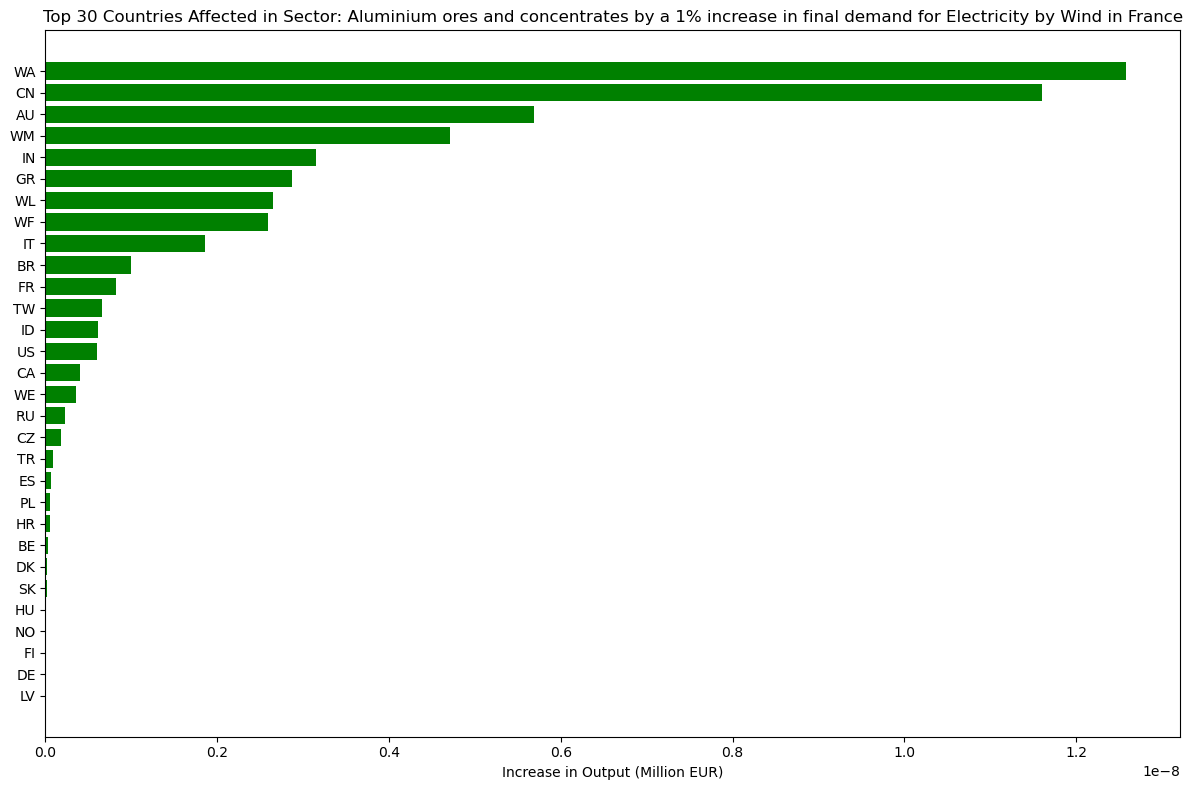

In [16]:
# Step 2: Create a shock vector with a 1% increase
shock_vector = pd.Series(0.0, index=exio3.Y.index)
shock_vector[("FR", "Electricity by wind")] = original_demand * 0.01  # 1% increase

# Step 3: Calculate the change in output using the Leontief inverse
delta_output = exio3.L @ shock_vector

# Step 4: Convert to DataFrame for filtering
delta_output_df = delta_output.reset_index()
delta_output_df.columns = ["Country", "Industry", "Output Change"]

# Step 5: Filter for the specific sector
sector_name = "Aluminium ores and concentrates"
filtered_sector = delta_output_df[delta_output_df["Industry"] == sector_name]

# Step 6: Sort and select top 30 countries affected
top_30_countries = filtered_sector.sort_values(by="Output Change", ascending=False).head(30)

# Step 7: Plot the results
plt.figure(figsize=(12, 8))
plt.barh(top_30_countries["Country"], top_30_countries["Output Change"], color='green')
plt.title(f"Top 30 Countries Affected in Sector: {sector_name} by a 1% increase in final demand for Electricity by Wind in France")
plt.xlabel("Increase in Output (Million EUR)")
plt.gca().invert_yaxis()
plt.tight_layout()


# Step 8: Save the figure BEFORE showing it
plt.savefig("wind_demand_france_aluminium_effects_top30.png", dpi=300)
plt.show()


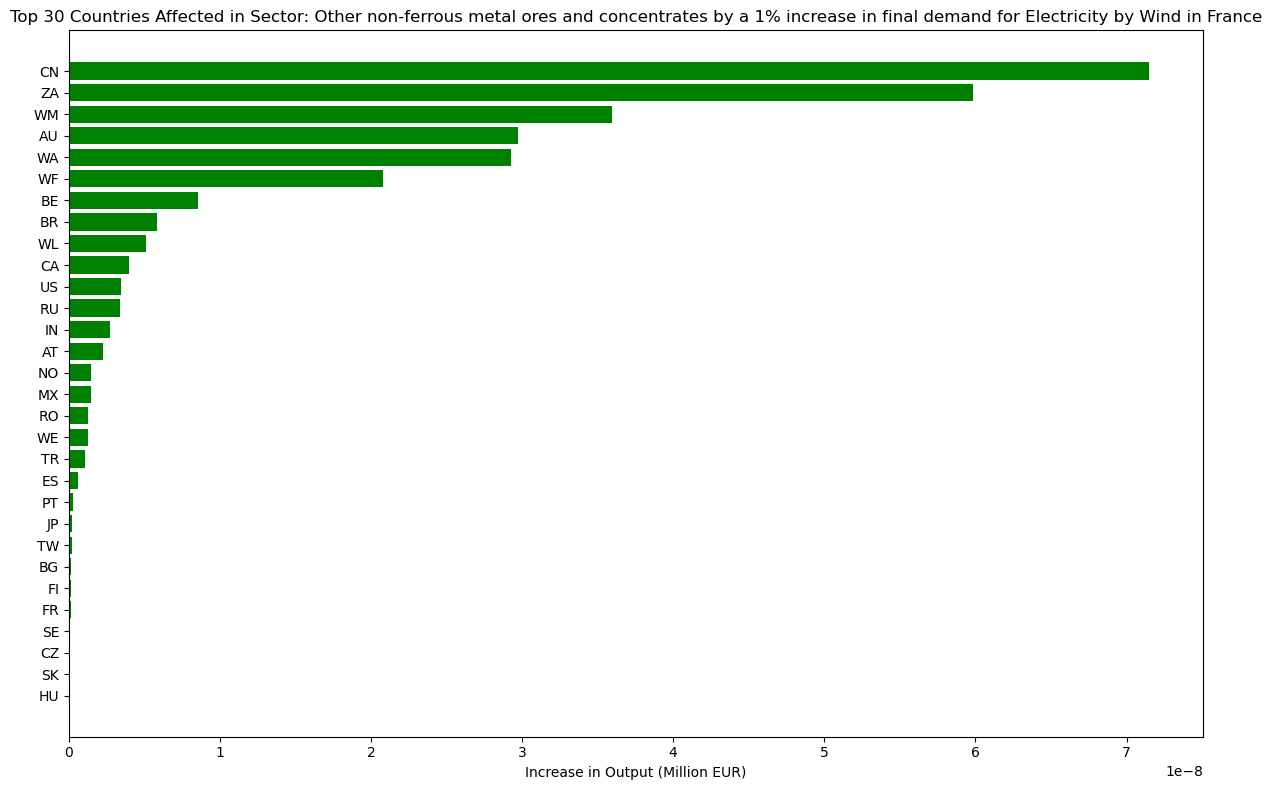

In [17]:
# Step 2: Create a shock vector with a 1% increase
shock_vector = pd.Series(0.0, index=exio3.Y.index)
shock_vector[("FR", "Electricity by wind")] = original_demand * 0.01  # 1% increase

# Step 3: Calculate the change in output using the Leontief inverse
delta_output = exio3.L @ shock_vector

# Step 4: Convert to DataFrame for filtering
delta_output_df = delta_output.reset_index()
delta_output_df.columns = ["Country", "Industry", "Output Change"]

# Step 5: Filter for the specific sector
sector_name = "Other non-ferrous metal ores and concentrates"
filtered_sector = delta_output_df[delta_output_df["Industry"] == sector_name]

# Step 6: Sort and select top 30 countries affected
top_30_countries = filtered_sector.sort_values(by="Output Change", ascending=False).head(30)

# Step 7: Plot the results
plt.figure(figsize=(12, 8))
plt.barh(top_30_countries["Country"], top_30_countries["Output Change"], color='green')
plt.title(f"Top 30 Countries Affected in Sector: {sector_name} by a 1% increase in final demand for Electricity by Wind in France")
plt.xlabel("Increase in Output (Million EUR)")
plt.gca().invert_yaxis()
plt.tight_layout()


# Step 8: Save the figure BEFORE showing it
plt.savefig("wind_demand_france_other_effects_top30.png", dpi=300)
plt.show()

In [13]:
# Extract final demand vector for wind electricity in France
final_demand_vector = exio3.Y.loc[("FR", "Electricity by wind")]

# Align vector with A matrix columns
final_demand_vector_aligned = final_demand_vector.reindex(exio3.A.columns)

# Multiply to get direct upstream inputs
direct_inputs = exio3.A @ final_demand_vector_aligned

# Convert to DataFrame
direct_inputs_df = direct_inputs.reset_index()
direct_inputs_df.columns = ["Country", "Industry", "Direct Input"]

# Sort and display top 30
top_upstream_sectors = direct_inputs_df.sort_values(by="Direct Input", ascending=False).head(30)
top_upstream_sectors

,Country,Industry,Direct Input
0,AT,Paddy rice,NaN
1,AT,Wheat,NaN
2,AT,Cereal grains nec,NaN
3,AT,"Vegetables, fruit, nuts",NaN
4,AT,Oil seeds,NaN
5,AT,"Sugar cane, sugar beet",NaN
6,AT,Plant-based fibers,NaN
7,AT,Crops nec,NaN
8,AT,Cattle,NaN
9,AT,Pigs,NaN


In [14]:
direct_inputs

region  sector                                           
AT      Paddy rice                                          NaN
        Wheat                                               NaN
        Cereal grains nec                                   NaN
        Vegetables, fruit, nuts                             NaN
        Oil seeds                                           NaN
                                                             ..
WM      Membership organisation services n.e.c. (91)        NaN
        Recreational, cultural and sporting services (92)   NaN
        Other services (93)                                 NaN
        Private households with employed persons (95)       NaN
        Extra-territorial organizations and bodies          NaN
Length: 9800, dtype: float64

In [18]:
exio3.Z.loc[:, ("FR", "Electricity by wind")].sort_values(ascending=False).head(40)

region  sector                                                                                                                
FR      Distribution services of gaseous fuels through mains                                                                      1675.932365
        Other business services (74)                                                                                                30.248586
        Retail trade services of motor fuel                                                                                         22.600250
        Financial intermediation services, except insurance and pension funding services (65)                                       21.698158
        Fabricated metal products, except machinery and equipment (28)                                                              18.170775
        Wholesale trade and commission trade services, except of motor vehicles and motorcycles (51)                                17.846113
        Renting servi

In [19]:
exio3.Z.loc[:, ("FR", "Electricity by solar photovoltaic")].sort_values(ascending=False).head(40)

region  sector                                                                                                                
FR      Distribution services of gaseous fuels through mains                                                                      526.933045
        Other business services (74)                                                                                                9.448598
        Financial intermediation services, except insurance and pension funding services (65)                                       6.777611
        Fabricated metal products, except machinery and equipment (28)                                                              5.676346
        Wholesale trade and commission trade services, except of motor vehicles and motorcycles (51)                                5.574489
        Renting services of machinery and equipment without operator and of personal and household goods (71)                       5.214346
DE      Machinery and equip